**Loading Data Set **

In [ ]:
import pandas as pd

df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**3 .Data Structure Understanding **

In [ ]:
df.shape # data set ka size hume isse pta padega
df.info() # then isse hume jankaari milengi ki kitne size ka h data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.columns = df.columns.str.strip() # column ke aage piche se space hataega jo helpful hoga
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

**Checking The target Column**

In [ ]:
df["loan_status"] = df["loan_status"].str.strip()
df["loan_status"].unique()

array(['Approved', 'Rejected'], dtype=object)

In [ ]:
df["loan_status"].unique() # isse hume target column me kitni value h pta padega

array([' Approved', ' Rejected'], dtype=object)

In [ ]:
df.select_dtypes(include='object').columns # Numeric ko choud ke object column bataega

Index(['education', 'self_employed', 'loan_status'], dtype='object')

**Encoding Phase**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [ ]:
X = df.drop("loan_status", axis=1) # ye target column hatadega
y = df["loan_status"] # ye Sirf target alag kar dega

X.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3415, 12)
Testing Data: (854, 12)


**Logistic Regression Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model banana
lr = LogisticRegression(max_iter=1000)

# Training
lr.fit(X_train, y_train)

# Prediction
y_pred_lr = lr.predict(X_test)

# Results
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8220140515222483

Confusion Matrix:
 [[492  44]
 [108 210]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87       536
           1       0.83      0.66      0.73       318

    accuracy                           0.82       854
   macro avg       0.82      0.79      0.80       854
weighted avg       0.82      0.82      0.82       854



In [ ]:
# Outlier Detection


**Random Forest  **

In [ ]:
# aab Random forest lagaenge
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9765807962529274

Confusion Matrix:
 [[527   9]
 [ 11 307]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



**Feature Importance Check**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
7,cibil_score,0.801838
6,loan_term,0.061950
5,loan_amount,0.027927
10,luxury_assets_value,0.016878
0,loan_id,0.016761
4,income_annum,0.016043
8,residential_assets_value,0.015732
11,bank_asset_value,0.015719
9,commercial_assets_value,0.015258
1,no_of_dependents,0.007455


**Plotting the Graph for that**

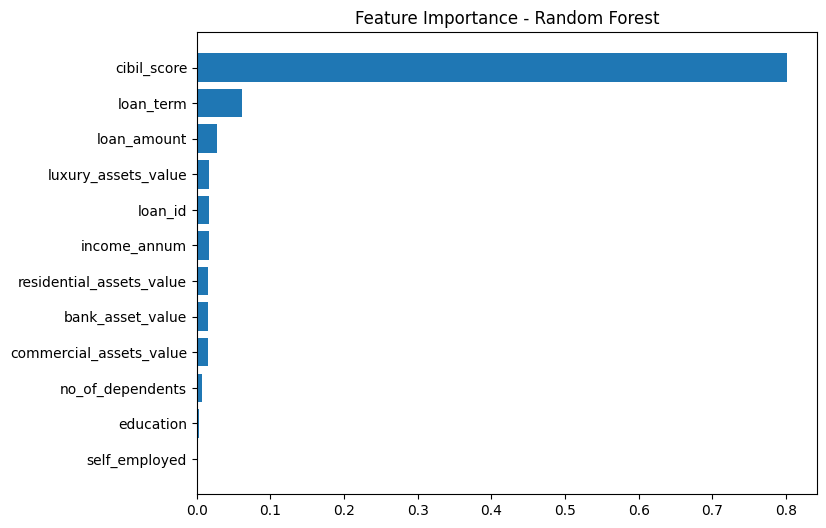

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()